In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import re

---

In [2]:
benchmark_file = Path(
    "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/seasonal_results/seasonal_basin_metrics_benchmark.csv"
)

challenger_files = [
    Path(
        "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/seasonal_results/seasonal_basin_metrics_challenger_group1.csv"
    ),
    Path(
        "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/seasonal_results/seasonal_basin_metrics_challenger_group2.csv"
    ),
]

benchmark_file = Path(
    "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/results/group_based_transfer_benchmark/benchmark_basin_metrics_0.csv"
)

challenger_files = [
    Path(
        "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/results/group_based_transfer/group1/basin_metrics_0.csv"
    ),
    Path(
        "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/results/group_based_transfer/group2/basin_metrics_0.csv"
    ),
]

In [3]:
import pandas as pd
from pathlib import Path


# Function to load benchmark metrics from a specific file path
def load_benchmark_metrics(file_path):
    """Load benchmark metrics from a specific CSV file"""
    try:
        metrics_df = pd.read_csv(file_path)
        metrics_df["model"] = "benchmark"
        return metrics_df
    except Exception as e:
        print(f"Error loading benchmark metrics from {file_path}: {e}")
        return pd.DataFrame()


# Function to load challenger metrics from specific CSV files
# This version infers the group name based on the file order.
def load_challenger_metrics(file_paths):
    """Load challenger metrics from specific CSV files and assign group names based on file order."""
    all_metrics = []
    for idx, file_path in enumerate(file_paths):
        try:
            # Infer group key based on index: first file is group1, second is group2, etc.
            group_key = f"group{idx + 1}"
            metrics_df = pd.read_csv(file_path)
            metrics_df["model"] = f"challenger_{group_key}"
            metrics_df["group"] = group_key
            all_metrics.append(metrics_df)
        except Exception as e:
            print(f"Error loading challenger metrics from {file_path}: {e}")
    if all_metrics:
        return pd.concat(all_metrics, ignore_index=True)
    else:
        return pd.DataFrame()


# Specify exact file paths
# Adjust the file paths below to match your file system
benchmark_file = Path(
    "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/seasonal_results/seasonal_basin_metrics_benchmark.csv"
)

challenger_files = [
    # Path(
    #     "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/seasonal_results/seasonal_basin_metrics_group1.csv"
    # ),
    Path(
        "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/seasonal_results/seasonal_basin_metrics_group2.csv"
    ),
]
# Load metrics with explicit file paths
benchmark_metrics = load_benchmark_metrics(benchmark_file)
challenger_metrics = load_challenger_metrics(challenger_files)

# Display info about loaded data
print(f"Benchmark metrics shape: {benchmark_metrics.shape}")
print(f"Challenger metrics shape: {challenger_metrics.shape}")

# Check loaded data
if not benchmark_metrics.empty:
    print("\nBenchmark metrics sample:")
    print(benchmark_metrics.head(5))

if not challenger_metrics.empty:
    print("\nChallenger metrics sample:")
    print(challenger_metrics.head(5))
    # Show unique groups in challenger metrics
    print("\nUnique challenger groups:")
    print(challenger_metrics["group"].unique())


Benchmark metrics shape: (480, 7)
Challenger metrics shape: (190, 8)

Benchmark metrics sample:
   basin_id  horizon       MSE       MAE       NSE      RMSE      model
0  CA_15013       10  1.130235  0.623087  0.449023  1.063125  benchmark
1  CA_15013        9  1.074500  0.609748  0.476193  1.036581  benchmark
2  CA_15013        8  1.061110  0.606827  0.482721  1.030102  benchmark
3  CA_15013        7  0.977216  0.581837  0.523618  0.988542  benchmark
4  CA_15013        6  0.910658  0.566234  0.556065  0.954284  benchmark

Challenger metrics sample:
   basin_id  horizon       MSE       MAE       NSE      RMSE  \
0  CA_15013       10  1.341141  0.752544  0.346209  1.158076   
1  CA_15013        9  1.310680  0.744075  0.361058  1.144849   
2  CA_15013        8  1.274886  0.735037  0.378507  1.129109   
3  CA_15013        7  1.190155  0.714358  0.419813  1.090942   
4  CA_15013        6  1.114398  0.694487  0.456743  1.055651   

               model   group  
0  challenger_group1  group1

In [4]:
# Function to extract and clean basin_id from index
def extract_basin_id(index_value):
    if isinstance(index_value, tuple):
        # Handle MultiIndex: (basin_id, horizon)
        basin_id = index_value[0]
    else:
        # Handle string index
        basin_id = index_value
    
    # Return as string and ensure it's a valid basin ID
    basin_id_str = str(basin_id)
    return basin_id_str

# Extract basin IDs
def extract_and_prep_metrics(df):
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Check if we're dealing with MultiIndex
    if isinstance(result_df.index, pd.MultiIndex):
        # Reset MultiIndex to get basin_id and horizon as columns
        result_df = result_df.reset_index()
    else:
        # Add basin_id column from index
        result_df['basin_id'] = result_df.index
        result_df = result_df.reset_index(drop=True)
    
    # Ensure basin_id is string
    result_df['basin_id'] = result_df['basin_id'].astype(str)
    
    # Filter for only CA basins
    result_df = result_df[result_df['basin_id'].str.startswith('CA_')]
    
    return result_df

# Process both datasets
benchmark_processed = extract_and_prep_metrics(benchmark_metrics)
challenger_processed = extract_and_prep_metrics(challenger_metrics)

# Find common CA basins
benchmark_basins = set(benchmark_processed['basin_id'])
challenger_basins = set(challenger_processed['basin_id'])
common_basins = benchmark_basins.intersection(challenger_basins)

print(f"Total benchmark CA basins: {len(benchmark_basins)}")
print(f"Total challenger CA basins: {len(challenger_basins)}")
print(f"Common CA basins: {len(common_basins)}")

# Filter both datasets to only include common basins
benchmark_common = benchmark_processed[benchmark_processed['basin_id'].isin(common_basins)]
challenger_common = challenger_processed[challenger_processed['basin_id'].isin(common_basins)]

# Show sample of aligned data
print("\nSample of benchmark data for common basins:")
print(benchmark_common.head())

print("\nSample of challenger data for common basins:")
print(challenger_common.head())

# Organize data by basin and horizon for easier comparison
def organize_by_basin_horizon(df):
    # If horizon is in the DataFrame columns
    if 'horizon' in df.columns:
        return df.set_index(['basin_id', 'horizon'])
    else:
        # If we're working with a MultiIndex already reset earlier
        print("Warning: 'horizon' column not found, using only basin_id as index")
        return df.set_index('basin_id')

benchmark_indexed = organize_by_basin_horizon(benchmark_common)
challenger_indexed = organize_by_basin_horizon(challenger_common)

Total benchmark CA basins: 0
Total challenger CA basins: 0
Common CA basins: 0

Sample of benchmark data for common basins:
Empty DataFrame
Columns: [basin_id, horizon, MSE, MAE, NSE, RMSE, model]
Index: []

Sample of challenger data for common basins:
Empty DataFrame
Columns: [basin_id, horizon, MSE, MAE, NSE, RMSE, model, group]
Index: []


In [5]:
# Direct comparison of basin IDs
benchmark_basins = set(benchmark_metrics['basin_id'])
challenger_basins = set(challenger_metrics['basin_id'])
common_basins = benchmark_basins.intersection(challenger_basins)

print(f"Number of basins in benchmark: {len(benchmark_basins)}")
print(f"Number of basins in challengers: {len(challenger_basins)}")
print(f"Number of common basins: {len(common_basins)}")
print("Sample common basins:", list(common_basins)[:5] if common_basins else "None")

# Function to compare performance without preprocessing
def compare_all_performance(benchmark_df, challenger_df, horizons=[i for i in range(1,11)], metrics=['NSE', 'RMSE']):
    """Compare performance between benchmark and challenger for all basins"""
    results = []
    
    # Get all unique basins
    all_basins = set(benchmark_df['basin_id']).intersection(challenger_df['basin_id'])
    
    for basin_id in all_basins:
        # Filter data for this basin
        benchmark_basin = benchmark_df[benchmark_df['basin_id'] == basin_id]
        
        # Get challenger data for this basin, could be from either group
        challenger_basin = challenger_df[challenger_df['basin_id'] == basin_id]
        
        # Get the group this basin belongs to
        group = challenger_basin['group'].iloc[0] if 'group' in challenger_basin else "Unknown"
        
        for horizon in horizons:
            benchmark_h = benchmark_basin[benchmark_basin['horizon'] == horizon]
            challenger_h = challenger_basin[challenger_basin['horizon'] == horizon]
            
            if benchmark_h.empty or challenger_h.empty:
                continue
                
            row = {
                'basin_id': basin_id,
                'horizon': horizon,
                'group': group
            }
            
            for metric in metrics:
                benchmark_val = benchmark_h[metric].values[0]
                challenger_val = challenger_h[metric].values[0]
                difference = challenger_val - benchmark_val
                
                row[f'benchmark_{metric}'] = benchmark_val
                row[f'challenger_{metric}'] = challenger_val
                row[f'diff_{metric}'] = difference
                
                # Add improvement flag (True if challenger is better)
                if metric == 'NSE':
                    # For NSE, higher is better
                    row[f'improved_{metric}'] = difference > 0
                else:
                    # For RMSE and MAE, lower is better
                    row[f'improved_{metric}'] = difference < 0
                    
            results.append(row)
    
    return pd.DataFrame(results)

# Compare performance for all basins
comparison_df = compare_all_performance(benchmark_metrics, challenger_metrics)

if not comparison_df.empty:
    # Summarize improvement by horizon
    horizon_summary = comparison_df.groupby('horizon').agg({
        'improved_NSE': 'mean',
        'improved_RMSE': 'mean',
        'diff_NSE': 'mean',
        'diff_RMSE': 'mean',
        'basin_id': 'count'
    }).rename(columns={'basin_id': 'count'})
    
    print("\nPerformance improvement by horizon (proportion of basins with improvement):")
    print(horizon_summary)
    
    # Summarize improvement by group
    if 'group' in comparison_df.columns:
        group_summary = comparison_df.groupby(['group', 'horizon']).agg({
            'improved_NSE': 'mean',
            'improved_RMSE': 'mean',
            'diff_NSE': 'mean',
            'diff_RMSE': 'mean',
            'basin_id': 'count'
        }).rename(columns={'basin_id': 'count'})
        
        print("\nPerformance improvement by group and horizon:")
        print(group_summary)
else:
    print("No common basins found for comparison")

Number of basins in benchmark: 48
Number of basins in challengers: 19
Number of common basins: 19
Sample common basins: ['CA_16134', 'CA_16055', 'CA_16068', 'CA_16205', 'CA_16100']

Performance improvement by horizon (proportion of basins with improvement):
         improved_NSE  improved_RMSE  diff_NSE  diff_RMSE  count
horizon                                                         
1            0.105263       0.105263 -0.080995   0.133441     19
2            0.105263       0.105263 -0.108378   0.147145     19
3            0.052632       0.052632 -0.130758   0.156433     19
4            0.052632       0.052632 -0.148685   0.162139     19
5            0.000000       0.000000 -0.159932   0.163048     19
6            0.000000       0.000000 -0.164256   0.157613     19
7            0.000000       0.000000 -0.177337   0.161944     19
8            0.000000       0.000000 -0.193380   0.169165     19
9            0.000000       0.000000 -0.209563   0.177256     19
10           0.000000      

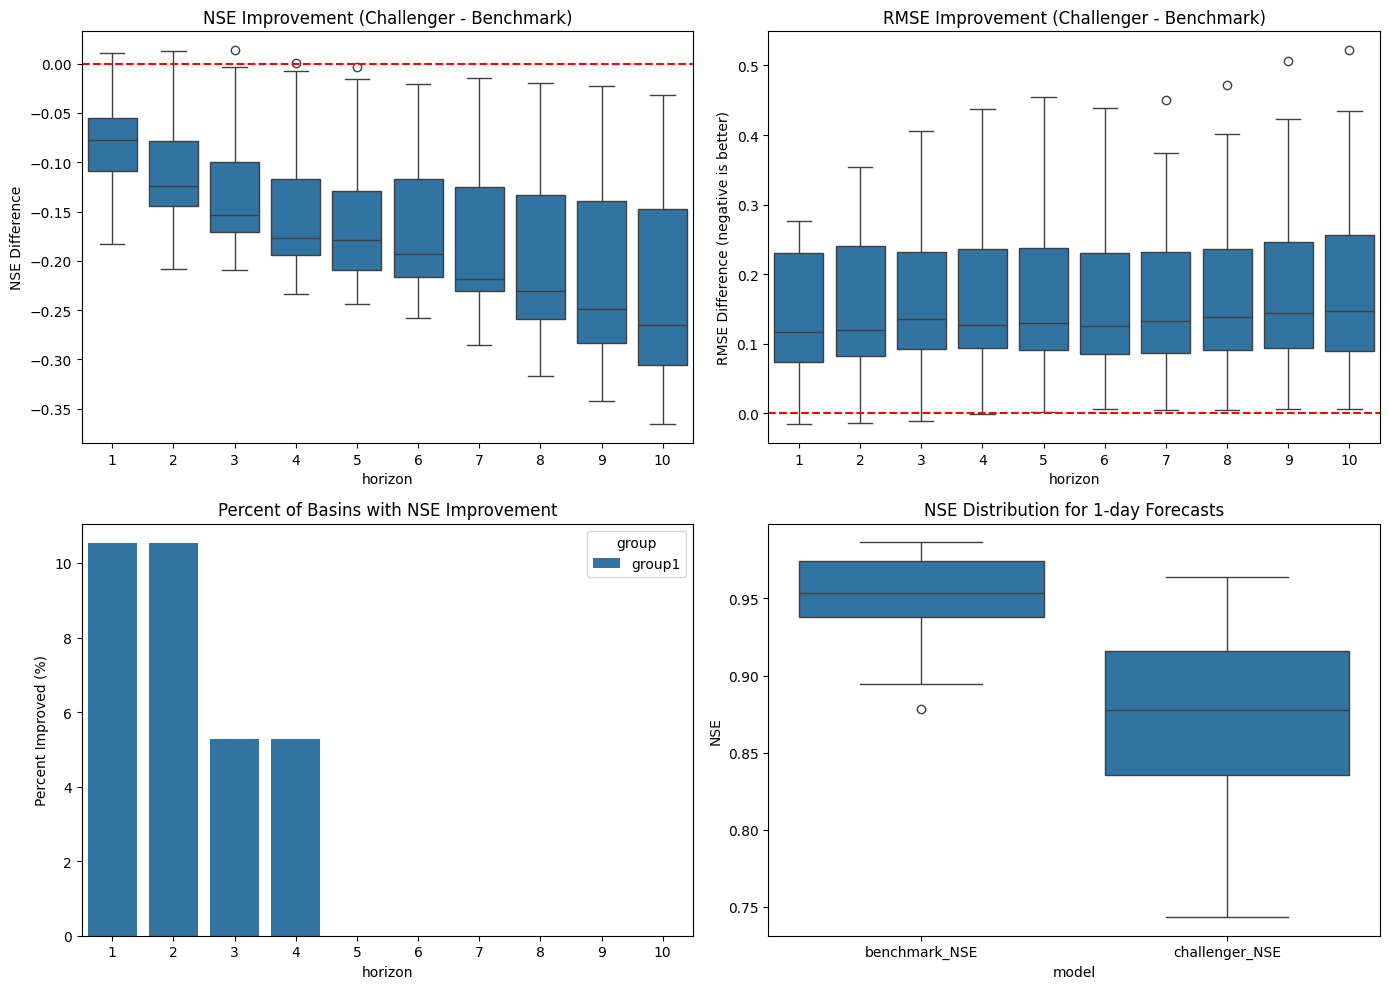


Number of basins with at least one improved horizon: 2

Analysis of basins with improvement:

Basin CA_17462 (Group: group1):
  Horizon 1: NSE improved by 0.0094 (Benchmark: 0.9398, Challenger: 0.9492)
  Horizon 2: NSE improved by 0.0003 (Benchmark: 0.8854, Challenger: 0.8857)

Basin CA_17100 (Group: group1):
  Horizon 1: NSE improved by 0.0107 (Benchmark: 0.9534, Challenger: 0.9641)
  Horizon 2: NSE improved by 0.0132 (Benchmark: 0.9065, Challenger: 0.9197)
  Horizon 3: NSE improved by 0.0138 (Benchmark: 0.8570, Challenger: 0.8708)
  Horizon 4: NSE improved by 0.0011 (Benchmark: 0.8166, Challenger: 0.8178)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

# 1. Plot NSE improvement distribution by horizon
plt.subplot(2, 2, 1)
sns.boxplot(x='horizon', y='diff_NSE', data=comparison_df)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('NSE Improvement (Challenger - Benchmark)')
plt.ylabel('NSE Difference')

# 2. Plot RMSE improvement distribution by horizon
plt.subplot(2, 2, 2)
sns.boxplot(x='horizon', y='diff_RMSE', data=comparison_df)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RMSE Improvement (Challenger - Benchmark)')
plt.ylabel('RMSE Difference (negative is better)')

# 3. Bar chart of improvement rate by group and horizon
group_horizon_counts = comparison_df.groupby(['group', 'horizon'])['improved_NSE'].mean()*100
group_horizon_df = group_horizon_counts.reset_index()

plt.subplot(2, 2, 3)
sns.barplot(x='horizon', y='improved_NSE', hue='group', data=group_horizon_df)
plt.title('Percent of Basins with NSE Improvement')
plt.ylabel('Percent Improved (%)')

# 4. Examine distribution of absolute performance
plt.subplot(2, 2, 4)
comparison_melted = pd.melt(
    comparison_df[comparison_df['horizon'] == 1],
    id_vars=['basin_id', 'group'],
    value_vars=['benchmark_NSE', 'challenger_NSE'],
    var_name='model', value_name='NSE'
)
sns.boxplot(x='model', y='NSE', data=comparison_melted)
plt.title('NSE Distribution for 1-day Forecasts')

plt.tight_layout()
# plt.savefig('performance_comparison.png', dpi=300)
plt.show()

# Additional detailed analysis
# Compare performance for basins where challenger performs better
improved_basins = comparison_df[comparison_df['improved_NSE'] == True]['basin_id'].unique()
print(f"\nNumber of basins with at least one improved horizon: {len(improved_basins)}")

if len(improved_basins) > 0:
    # Look at those basins specifically
    improved_comparison = comparison_df[comparison_df['basin_id'].isin(improved_basins)]
    print("\nAnalysis of basins with improvement:")
    for basin in improved_basins:
        basin_data = improved_comparison[improved_comparison['basin_id'] == basin]
        print(f"\nBasin {basin} (Group: {basin_data['group'].iloc[0]}):")
        for _, row in basin_data.iterrows():
            if row['improved_NSE']:
                print(f"  Horizon {int(row['horizon'])}: NSE improved by {row['diff_NSE']:.4f} (Benchmark: {row['benchmark_NSE']:.4f}, Challenger: {row['challenger_NSE']:.4f})")

Generating performance comparison plots...


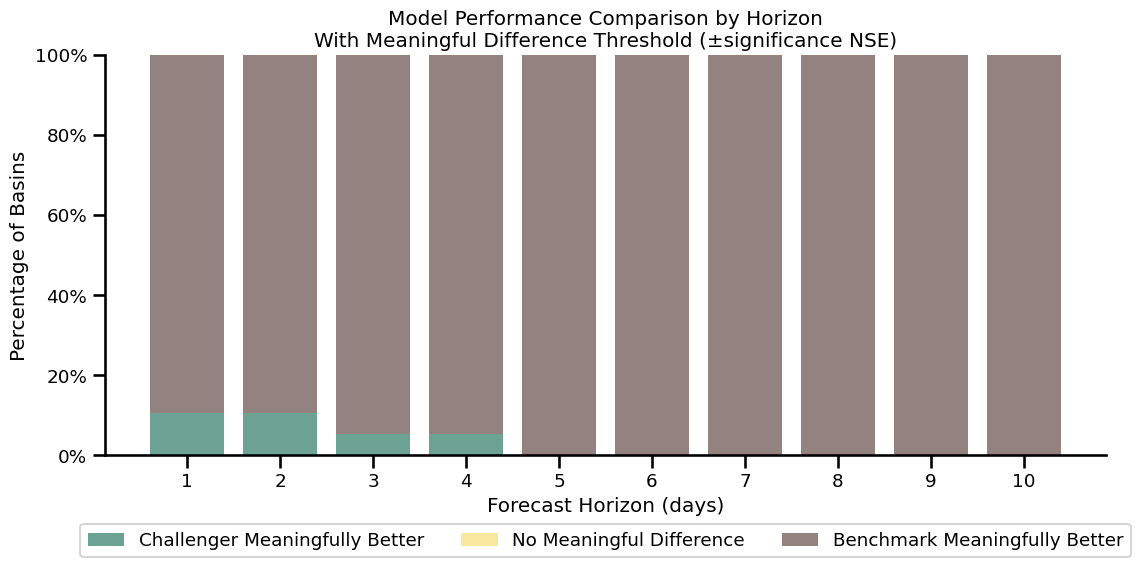

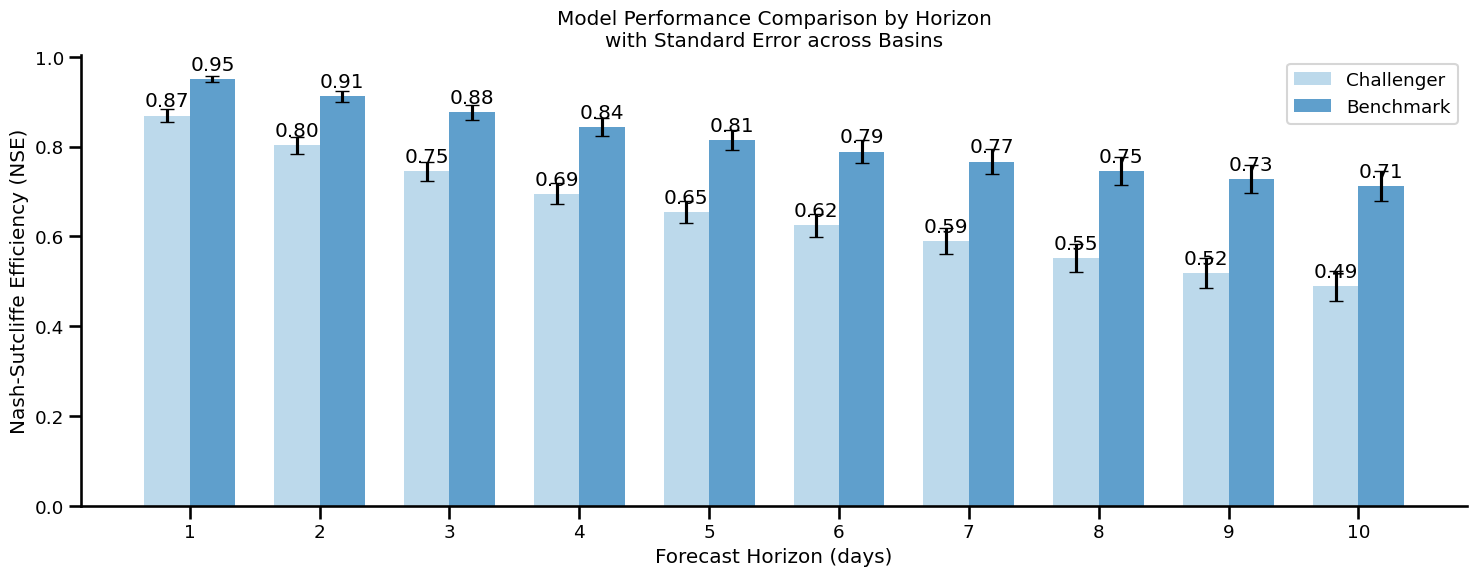

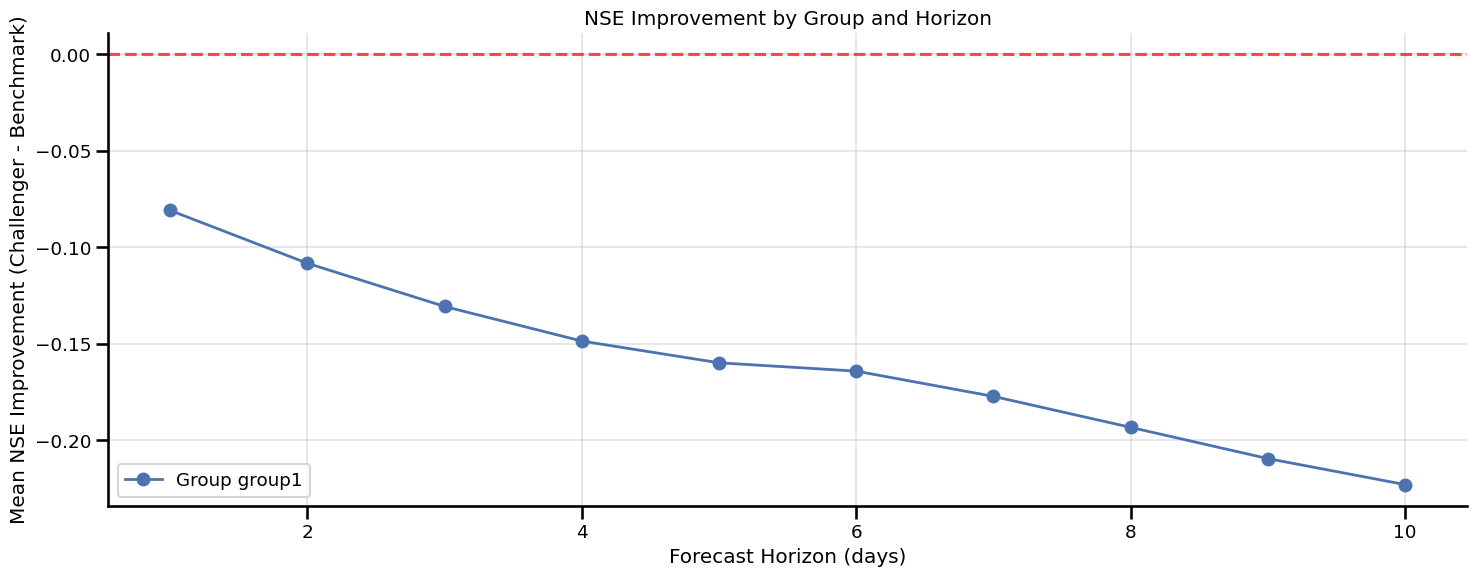


Performance Summary:
Horizon 1: 10.5% better, 0.0% similar, 89.5% worse
Horizon 2: 10.5% better, 0.0% similar, 89.5% worse
Horizon 3: 5.3% better, 0.0% similar, 94.7% worse
Horizon 4: 5.3% better, 0.0% similar, 94.7% worse
Horizon 5: 0.0% better, 0.0% similar, 100.0% worse
Horizon 6: 0.0% better, 0.0% similar, 100.0% worse
Horizon 7: 0.0% better, 0.0% similar, 100.0% worse
Horizon 8: 0.0% better, 0.0% similar, 100.0% worse
Horizon 9: 0.0% better, 0.0% similar, 100.0% worse
Horizon 10: 0.0% better, 0.0% similar, 100.0% worse

Mean NSE values:
Horizon 1: Challenger: 0.8689, Benchmark: 0.9499, Difference: -0.0810
Horizon 2: Challenger: 0.8032, Benchmark: 0.9116, Difference: -0.1084
Horizon 3: Challenger: 0.7453, Benchmark: 0.8761, Difference: -0.1308
Horizon 4: Challenger: 0.6946, Benchmark: 0.8433, Difference: -0.1487
Horizon 5: Challenger: 0.6544, Benchmark: 0.8143, Difference: -0.1599
Horizon 6: Challenger: 0.6244, Benchmark: 0.7887, Difference: -0.1643
Horizon 7: Challenger: 0.5895, 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

significance = 0.00

# Set style for all plots
sns.set_palette("deep")
sns.set_context("talk", font_scale=0.8)

# Since we only have one run, we'll simulate the statistical test 
# by determining if improvement is meaningful rather than statistically significant
def plot_performance_comparison(comparison_df):
    """Create stacked bar plot of performance comparison."""
    pastel_green = "#6BA292"
    pastel_red = "#93827F"
    pastel_yellow = "#F9E79F"
    
    # Prepare data by horizon
    horizons = sorted(comparison_df['horizon'].unique())
    results = []
    
    for horizon in horizons:
        horizon_data = comparison_df[comparison_df['horizon'] == horizon]
        total_basins = len(horizon_data)
        
        # We'll consider improvements > significance as meaningful for NSE
        better = (horizon_data['diff_NSE'] > significance).sum()
        worse = (horizon_data['diff_NSE'] < -significance).sum()
        insignificant = total_basins - better - worse
        
        results.append({
            'horizon': horizon,
            'better': (better / total_basins) * 100,
            'insignificant': (insignificant / total_basins) * 100,
            'worse': (worse / total_basins) * 100
        })
    
    result_df = pd.DataFrame(results)
    
    plt.figure(figsize=(12, 6))
    
    plt.bar(
        result_df["horizon"],
        result_df["better"],
        label="Challenger Meaningfully Better",
        color=pastel_green,
    )
    plt.bar(
        result_df["horizon"],
        result_df["insignificant"],
        bottom=result_df["better"],
        label="No Meaningful Difference",
        color=pastel_yellow,
    )
    plt.bar(
        result_df["horizon"],
        result_df["worse"],
        bottom=result_df["better"] + result_df["insignificant"],
        label="Benchmark Meaningfully Better",
        color=pastel_red,
    )

    plt.xlabel("Forecast Horizon (days)")
    plt.ylabel("Percentage of Basins")
    plt.title("Model Performance Comparison by Horizon\nWith Meaningful Difference Threshold (±significance NSE)")
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.ylim(0, 100)

    sns.despine()
    plt.yticks(np.arange(0, 101, 20), [f"{i}%" for i in range(0, 101, 20)])
    plt.xticks(result_df["horizon"])

    plt.tight_layout()
    # plt.savefig('performance_comparison_stacked.png', dpi=300)
    plt.show()
    
    return result_df

def plot_nse_comparison(comparison_df):
    """Create bar plot comparing NSE scores between models."""
    horizons = sorted(comparison_df['horizon'].unique())
    
    # Calculate mean NSE for each horizon and model
    results = []
    for horizon in horizons:
        horizon_data = comparison_df[comparison_df['horizon'] == horizon]
        
        # Calculate means
        ch_mean = horizon_data['challenger_NSE'].mean()
        bm_mean = horizon_data['benchmark_NSE'].mean()
        
        # Calculate standard error (we don't have multiple runs, so use variability across basins)
        ch_std = horizon_data['challenger_NSE'].std() / np.sqrt(len(horizon_data))
        bm_std = horizon_data['benchmark_NSE'].std() / np.sqrt(len(horizon_data))
        
        results.append({
            'horizon': horizon,
            'ch_mean': ch_mean,
            'bm_mean': bm_mean,
            'ch_std': ch_std,
            'bm_std': bm_std
        })
    
    result_df = pd.DataFrame(results)
    
    plt.figure(figsize=(15, 6))
    bar_width = 0.35
    x_pos = np.arange(len(horizons))
    
    colors = sns.color_palette("Blues", 2)
    
    # Plot bars with error bars
    plt.bar(
        x_pos - bar_width / 2,
        result_df['ch_mean'],
        bar_width,
        yerr=result_df['ch_std'],
        label="Challenger",
        color=colors[0],
        capsize=5,
        alpha=0.8,
    )
    plt.bar(
        x_pos + bar_width / 2,
        result_df['bm_mean'],
        bar_width,
        yerr=result_df['bm_std'],
        label="Benchmark",
        color=colors[1],
        capsize=5,
        alpha=0.8,
    )

    plt.xlabel("Forecast Horizon (days)")
    plt.ylabel("Nash-Sutcliffe Efficiency (NSE)")
    plt.title("Model Performance Comparison by Horizon\nwith Standard Error across Basins")
    plt.xticks(x_pos, horizons)
    plt.legend()
    sns.despine()

    # Add value labels
    for i, (ch, bm) in enumerate(zip(result_df['ch_mean'], result_df['bm_mean'])):
        plt.text(i - bar_width / 2, ch + 0.02, f"{ch:.2f}", ha="center")
        plt.text(i + bar_width / 2, bm + 0.02, f"{bm:.2f}", ha="center")

    plt.tight_layout()
    # plt.savefig('nse_comparison_bars.png', dpi=300)
    plt.show()
    
    return result_df

# Let's create separate plots for each group to see if there are differences
def plot_group_comparison(comparison_df):
    """Create bar plots comparing NSE improvements by group."""
    horizons = sorted(comparison_df['horizon'].unique())
    groups = sorted(comparison_df['group'].unique())
    
    plt.figure(figsize=(15, 6))
    
    for i, group in enumerate(groups):
        group_data = comparison_df[comparison_df['group'] == group]
        means = [group_data[group_data['horizon'] == h]['diff_NSE'].mean() for h in horizons]
        plt.plot(horizons, means, marker='o', label=f"Group {group}", linewidth=2)
    
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.7)
    plt.xlabel("Forecast Horizon (days)")
    plt.ylabel("Mean NSE Improvement (Challenger - Benchmark)")
    plt.title("NSE Improvement by Group and Horizon")
    plt.legend()
    plt.grid(alpha=0.3)
    sns.despine()
    plt.tight_layout()
    # plt.savefig('group_comparison.png', dpi=300)
    plt.show()

# Generate the plots
print("Generating performance comparison plots...")
result_df = plot_performance_comparison(comparison_df)
nse_df = plot_nse_comparison(comparison_df)
plot_group_comparison(comparison_df)

# Print summary statistics
print("\nPerformance Summary:")
for horizon in sorted(result_df['horizon'].unique()):
    row = result_df[result_df['horizon'] == horizon].iloc[0]
    print(f"Horizon {int(horizon)}: {row['better']:.1f}% better, {row['insignificant']:.1f}% similar, {row['worse']:.1f}% worse")

print("\nMean NSE values:")
for horizon in sorted(nse_df['horizon'].unique()):
    row = nse_df[nse_df['horizon'] == horizon].iloc[0]
    print(f"Horizon {int(horizon)}: Challenger: {row['ch_mean']:.4f}, Benchmark: {row['bm_mean']:.4f}, Difference: {row['ch_mean']-row['bm_mean']:.4f}")

# Generate a breakdown by group
group_summary = comparison_df.groupby(['group', 'horizon']).agg({
    'diff_NSE': ['mean', 'std'],
    'improved_NSE': 'mean'
}).reset_index()

group_summary.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in group_summary.columns]

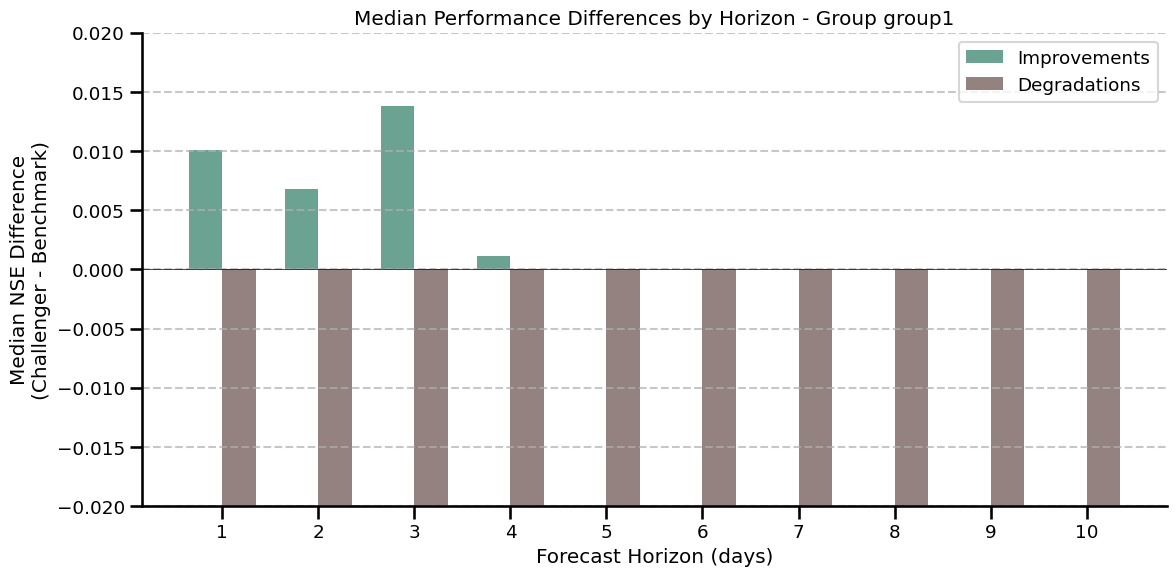

In [8]:
def plot_performance_differences_by_group(comparison_df):
   # Get unique groups
   groups = sorted(comparison_df['group'].unique())
   
   for group in groups:
       # Filter data for this group
       group_data = comparison_df[comparison_df['group'] == group]
       
       # Calculate median improvement and degradation by horizon
       analysis_data = []
       
       for horizon in sorted(group_data['horizon'].unique()):
           horizon_data = group_data[group_data['horizon'] == horizon]
           
           # Get improvements (positive diff_NSE)
           improvements = horizon_data[horizon_data['diff_NSE'] > 0]['diff_NSE']
           median_improvement = improvements.median() if not improvements.empty else 0
           
           # Get degradations (negative diff_NSE)
           degradations = horizon_data[horizon_data['diff_NSE'] < 0]['diff_NSE']
           median_degradation = degradations.median() if not degradations.empty else 0
           
           analysis_data.append({
               'horizon': horizon,
               'median_improvement': median_improvement,
               'median_degradation': median_degradation
           })
       
       analysis_df = pd.DataFrame(analysis_data)
       
       # Plot
       plt.figure(figsize=(12, 6))
       
       x = analysis_df["horizon"].values
       width = 0.35
       
       # Plot improvements and degradations
       plt.bar(
           x - width / 2,
           analysis_df["median_improvement"],
           width,
           label="Improvements",
           color="#6BA292",
       )
       plt.bar(
           x + width / 2,
           analysis_df["median_degradation"],
           width,
           label="Degradations",
           color="#93827F",
       )
       
       # Add reference line at y=0
       plt.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
       
       # Customize plot
       plt.xlabel("Forecast Horizon (days)")
       plt.ylabel("Median NSE Difference\n(Challenger - Benchmark)")
       plt.title(f"Median Performance Differences by Horizon - Group {group}")
       plt.legend()
       
       # Set x-axis ticks
       plt.xticks(x)
       
       plt.ylim(-0.02, 0.02)  # Adjusted based on data range
       
       # Add grid
       plt.grid(True, axis="y", linestyle="--", alpha=0.7)
       
       # Remove top and right spines
       sns.despine()
       
       plt.tight_layout()
    #    plt.savefig(f'performance_diff_group_{group}.png', dpi=300)
       plt.show()

# Call the function to create plots
plot_performance_differences_by_group(comparison_df)

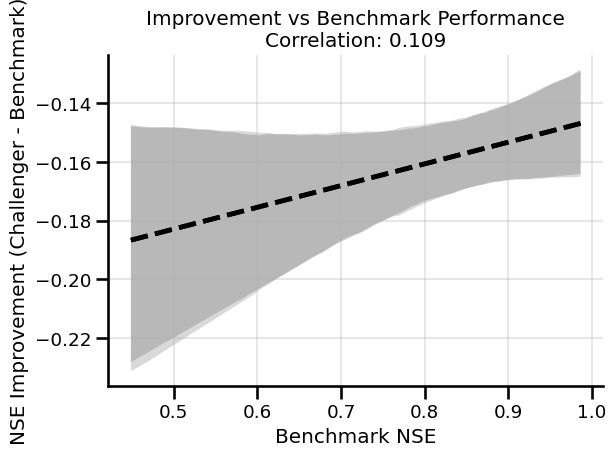

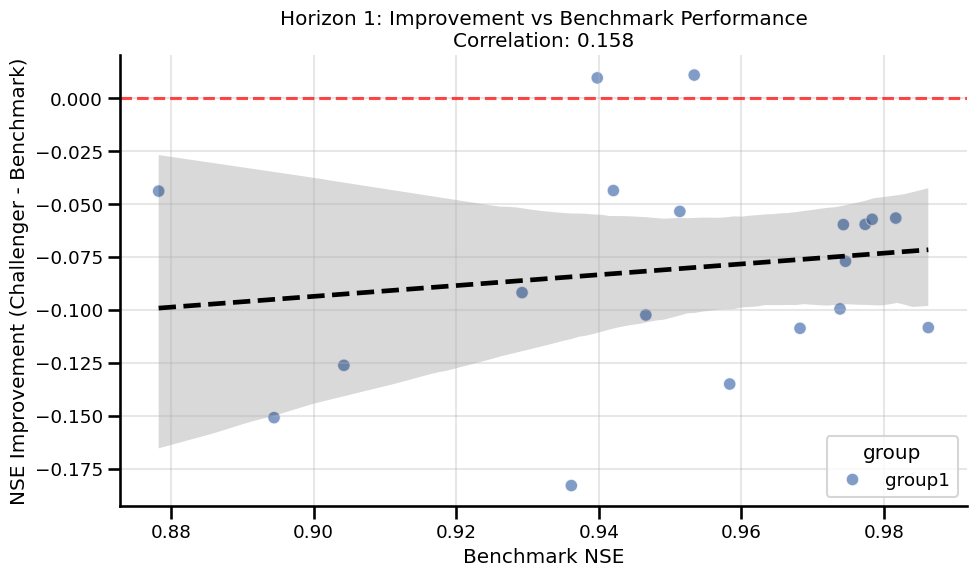

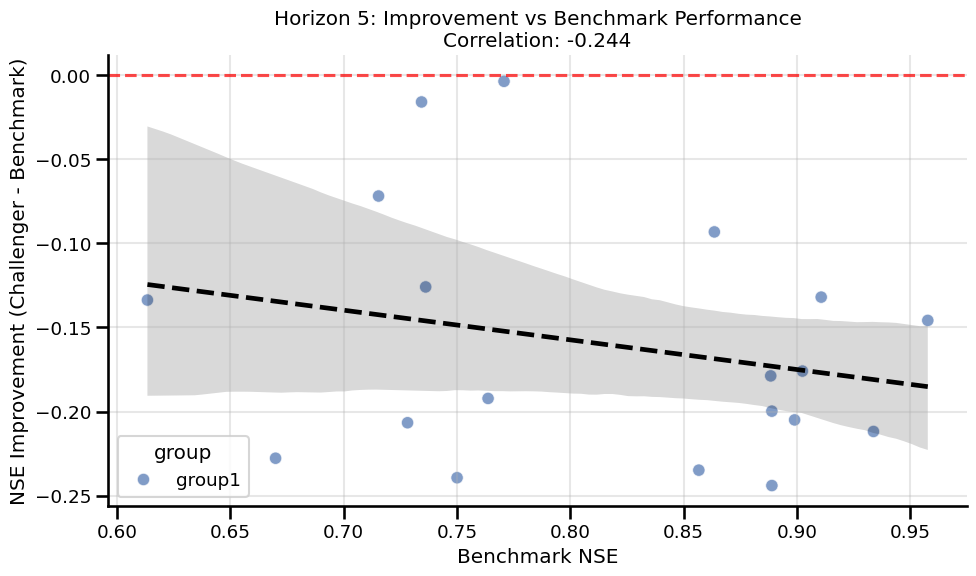

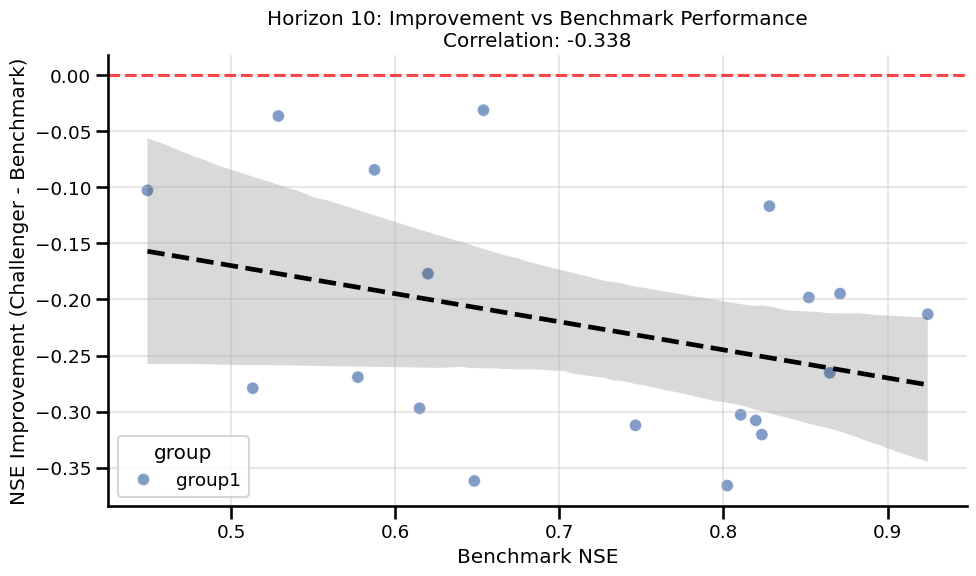

In [9]:
# Add regression line to see trend
sns.regplot(
    data=comparison_df,
    x="benchmark_NSE",
    y="diff_NSE",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"},
)

# Add regression line to see trend
sns.regplot(
    data=comparison_df,
    x="benchmark_NSE",
    y="diff_NSE",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"},
)

# Calculate correlation
correlation = comparison_df["benchmark_NSE"].corr(comparison_df["diff_NSE"])

plt.title(f"Improvement vs Benchmark Performance\nCorrelation: {correlation:.3f}")
plt.xlabel("Benchmark NSE")
plt.ylabel("NSE Improvement (Challenger - Benchmark)")
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
# plt.savefig("improvement_vs_baseline.png", dpi=300)
plt.show()

# Split by horizon for more detailed analysis
for horizon in [1, 5, 10]:  # Select a few key horizons
    h_data = comparison_df[comparison_df["horizon"] == horizon]

    if h_data.empty:
        continue

    plt.figure(figsize=(10, 6))
    plt.axhline(y=0, color="r", linestyle="--", alpha=0.7)

    sns.scatterplot(
        data=h_data, x="benchmark_NSE", y="diff_NSE", hue="group", alpha=0.7, s=80
    )

    # Add regression line
    sns.regplot(
        data=h_data,
        x="benchmark_NSE",
        y="diff_NSE",
        scatter=False,
        color="black",
        line_kws={"linestyle": "--"},
    )

    h_corr = h_data["benchmark_NSE"].corr(h_data["diff_NSE"])

    plt.title(
        f"Horizon {horizon}: Improvement vs Benchmark Performance\nCorrelation: {h_corr:.3f}"
    )
    plt.xlabel("Benchmark NSE")
    plt.ylabel("NSE Improvement (Challenger - Benchmark)")
    plt.grid(alpha=0.3)
    sns.despine()
    plt.tight_layout()
    # plt.savefig(f"improvement_vs_baseline_h{horizon}.png", dpi=300)
    plt.show()

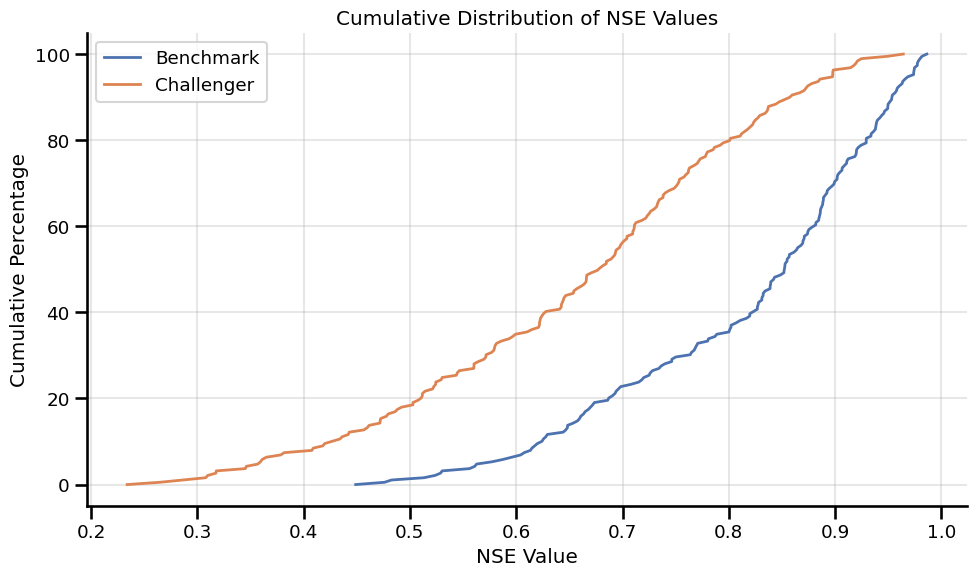

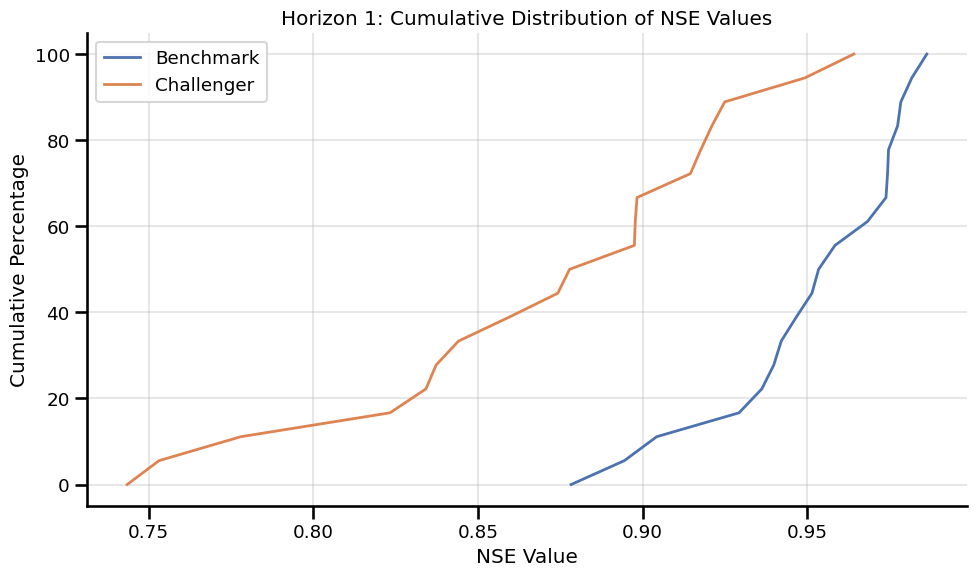

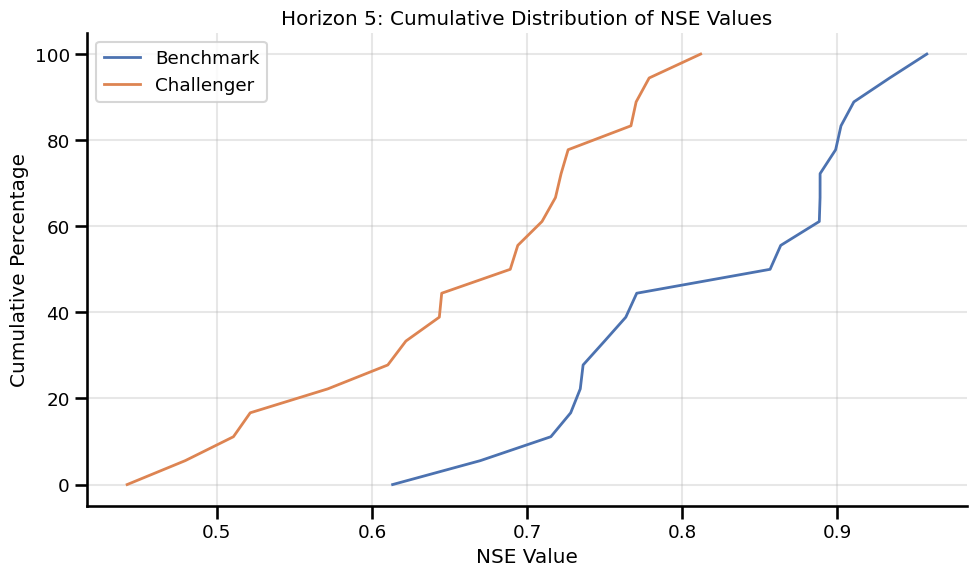

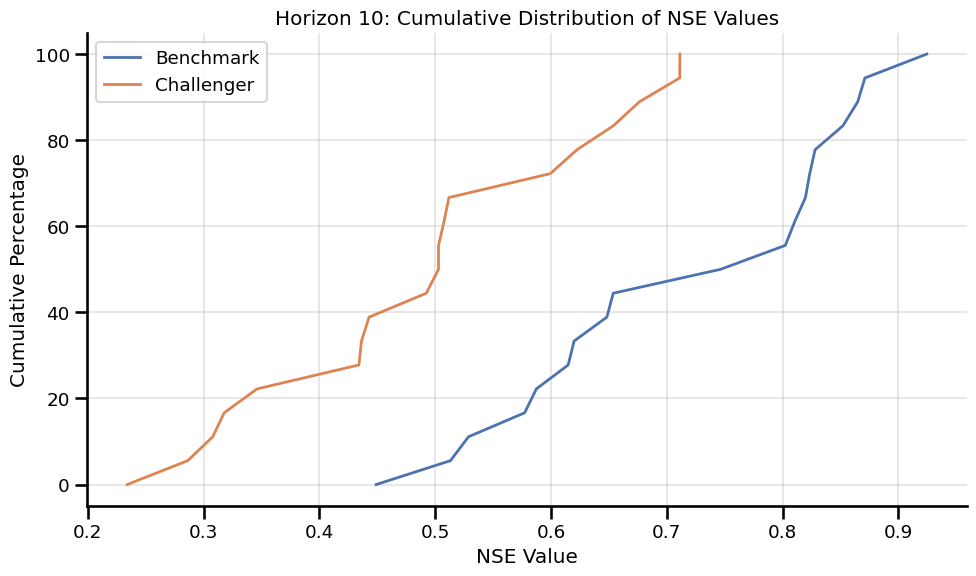

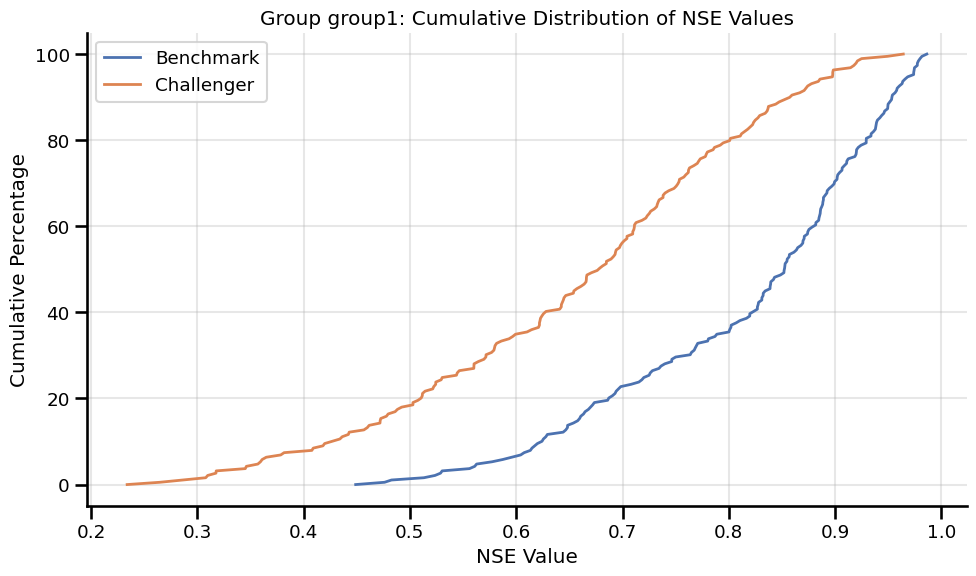

In [10]:
# Prepare data for CDF
def plot_nse_cdf():
    # Create a DataFrame for CDF plotting
    cdf_data = pd.DataFrame(
        {
            "Benchmark": comparison_df["benchmark_NSE"],
            "Challenger": comparison_df["challenger_NSE"],
        }
    )

    # Calculate empirical CDFs
    for column in cdf_data.columns:
        # Sort values
        sorted_data = np.sort(cdf_data[column])
        # Calculate cumulative probabilities
        p = 100.0 * np.arange(len(sorted_data)) / (len(sorted_data) - 1)
        # Store in new columns
        cdf_data[f"{column}_sorted"] = sorted_data
        cdf_data[f"{column}_p"] = p

    # Plot CDF
    plt.figure(figsize=(10, 6))

    plt.plot(
        cdf_data["Benchmark_sorted"],
        cdf_data["Benchmark_p"],
        label="Benchmark",
        linewidth=2,
    )
    plt.plot(
        cdf_data["Challenger_sorted"],
        cdf_data["Challenger_p"],
        label="Challenger",
        linewidth=2,
    )

    plt.title("Cumulative Distribution of NSE Values")
    plt.xlabel("NSE Value")
    plt.ylabel("Cumulative Percentage")
    plt.grid(alpha=0.3)
    plt.legend()
    sns.despine()
    plt.tight_layout()
    # plt.savefig("nse_cdf.png", dpi=300)
    plt.show()

    return cdf_data


# Generate the overall CDF
cdf_data = plot_nse_cdf()

# Plot CDFs by horizon
for horizon in [1, 5, 10]:  # Key horizons
    h_data = comparison_df[comparison_df["horizon"] == horizon]

    if h_data.empty:
        continue

    # Prepare data for this horizon
    cdf_h_data = pd.DataFrame(
        {"Benchmark": h_data["benchmark_NSE"], "Challenger": h_data["challenger_NSE"]}
    )

    # Calculate empirical CDFs
    for column in cdf_h_data.columns:
        sorted_data = np.sort(cdf_h_data[column])
        p = 100.0 * np.arange(len(sorted_data)) / (len(sorted_data) - 1)
        cdf_h_data[f"{column}_sorted"] = sorted_data
        cdf_h_data[f"{column}_p"] = p

    # Plot CDF for this horizon
    plt.figure(figsize=(10, 6))

    plt.plot(
        cdf_h_data["Benchmark_sorted"],
        cdf_h_data["Benchmark_p"],
        label="Benchmark",
        linewidth=2,
    )
    plt.plot(
        cdf_h_data["Challenger_sorted"],
        cdf_h_data["Challenger_p"],
        label="Challenger",
        linewidth=2,
    )

    plt.title(f"Horizon {horizon}: Cumulative Distribution of NSE Values")
    plt.xlabel("NSE Value")
    plt.ylabel("Cumulative Percentage")
    plt.grid(alpha=0.3)
    plt.legend()
    sns.despine()
    plt.tight_layout()
    # plt.savefig(f"nse_cdf_h{horizon}.png", dpi=300)
    plt.show()

# Additional analysis: CDF split by group
for group in comparison_df["group"].unique():
    group_data = comparison_df[comparison_df["group"] == group]

    # Prepare data for this group
    cdf_g_data = pd.DataFrame(
        {
            "Benchmark": group_data["benchmark_NSE"],
            "Challenger": group_data["challenger_NSE"],
        }
    )

    # Calculate empirical CDFs
    for column in cdf_g_data.columns:
        sorted_data = np.sort(cdf_g_data[column])
        p = 100.0 * np.arange(len(sorted_data)) / (len(sorted_data) - 1)
        cdf_g_data[f"{column}_sorted"] = sorted_data
        cdf_g_data[f"{column}_p"] = p

    # Plot CDF for this group
    plt.figure(figsize=(10, 6))

    plt.plot(
        cdf_g_data["Benchmark_sorted"],
        cdf_g_data["Benchmark_p"],
        label="Benchmark",
        linewidth=2,
    )
    plt.plot(
        cdf_g_data["Challenger_sorted"],
        cdf_g_data["Challenger_p"],
        label="Challenger",
        linewidth=2,
    )

    plt.title(f"Group {group}: Cumulative Distribution of NSE Values")
    plt.xlabel("NSE Value")
    plt.ylabel("Cumulative Percentage")
    plt.grid(alpha=0.3)
    plt.legend()
    sns.despine()
    plt.tight_layout()
    # plt.savefig(f"nse_cdf_group_{group}.png", dpi=300)
    plt.show()

/var/folders/y6/kqwqph4s3sj7hkxryrly5y6r0000gn/T/ipykernel_29729/3355490397.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['epoch'] = df['epoch'].fillna(method='ffill')


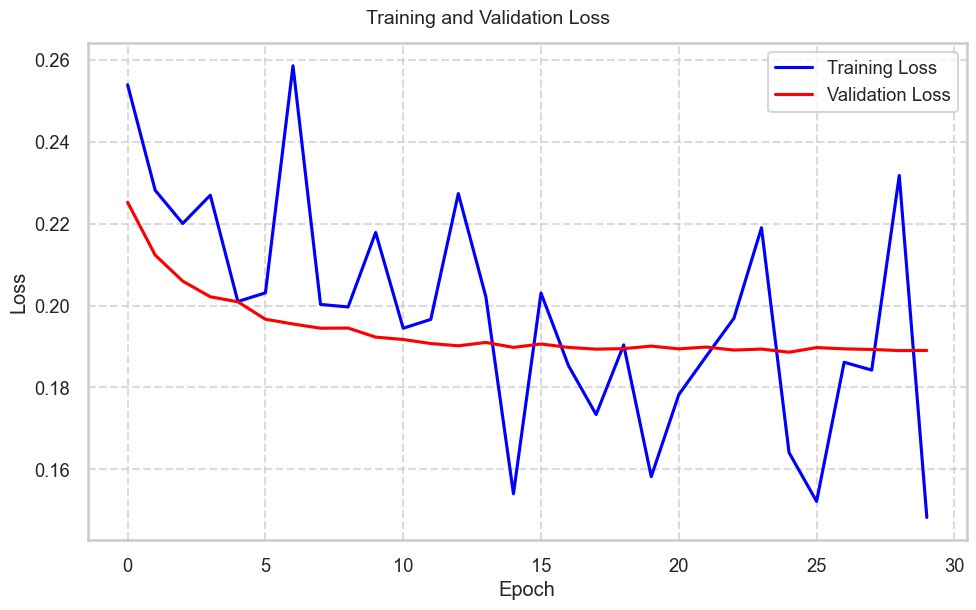

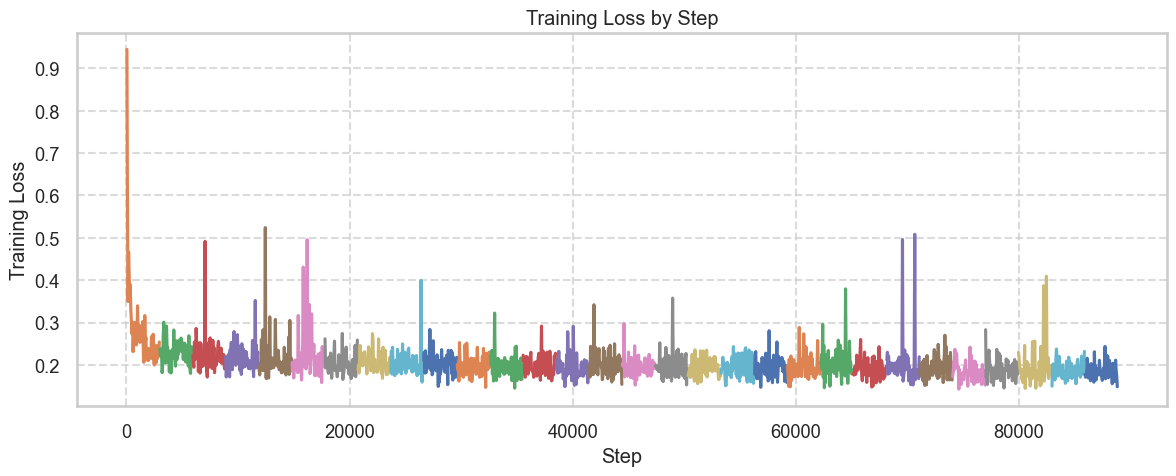

In [22]:
def plot_training_curves(csv_path):
    """
    Plot learning curves from training logs.
    
    Args:
        csv_path: Path to the CSV file containing training logs
    """
    # Read CSV file
    df = pd.read_csv(csv_path)
    
    # Clean up data - forward fill epoch values
    df['epoch'] = df['epoch'].fillna(method='ffill')
    
    # Convert epoch to integer for proper plotting
    df['epoch'] = df['epoch'].astype(float).astype('Int64')
    
    # Get unique epochs
    epochs = df['epoch'].dropna().unique()
    
    # Group data by epoch
    epoch_data = []
    for epoch in epochs:
        epoch_df = df[df['epoch'] == epoch]
        metrics_dict = {'epoch': epoch}
        
        # Find all metrics columns (train_* and val_*)
        for col in df.columns:
            if col.startswith('train_') or col.startswith('val_'):
                # Use the last value per epoch for each metric
                metrics_dict[col] = epoch_df[col].dropna().iloc[-1] if not epoch_df[col].dropna().empty else np.nan
        
        epoch_data.append(metrics_dict)
    
    # Create DataFrame with epoch averages
    epoch_df = pd.DataFrame(epoch_data)
    
    # Set up style
    sns.set_style("whitegrid")
    
    # Create figure with two subplots for loss and MSE
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plot loss metrics
    if 'train_loss' in epoch_df.columns:
        ax1.plot(epoch_df['epoch'], epoch_df['train_loss'], 'b-', label='Training Loss')
    if 'val_loss' in epoch_df.columns:
        ax1.plot(epoch_df['epoch'], epoch_df['val_loss'], 'r-', label='Validation Loss')
    ax1.set_ylabel('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.suptitle('Training and Validation Loss', fontsize=14, y=1.02)
    plt.show()
    
    # Create step plot
    plt.figure(figsize=(12, 5))
    step_df = df[df['step'].notna()]
    
    # Plot train loss by step, colored by epoch
    for epoch in step_df['epoch'].unique():
        epoch_data = step_df[step_df['epoch'] == epoch]
        plt.plot(epoch_data['step'], epoch_data['train_loss'], label=f'Epoch {epoch}')
    
    plt.xlabel('Step')
    plt.ylabel('Training Loss')
    plt.title('Training Loss by Step')
    # plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

path_to_logs = Path("/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/logs/group_based_transfer/group2/train_run0_20250306_141036/version_0/metrics.csv")

# Call the function to plot training curves
plot_training_curves(path_to_logs)